# Parkinson Disease Early Detection
in this project, we will use machine learning algorithms to detect parkinson disease using multimodal dataset (voice records and images).
<b> in the begining, </b> we will install and import necessary modules and read our dataset.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [79]:
# import modules
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score, confusion_matrix
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.utils import shuffle
import librosa

***in the begining,*** we will deal with dataset thet contain features extracted from voice records (parkinson and healthy people), we will **preprocess** it, **visualize** it, **understand** it, and **extract features** from it.

In [112]:
# Specify the file path
file_path = "/content/drive/MyDrive/multimodal project/datasets/voice/Parkinsson disease.csv"

# Read data from the CSV file
data = pd.read_csv(file_path)

In [113]:
# show the first five samples
data.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


# Data Distribution
we will visualize data distribution, this proess help us to understand dataset deeply.


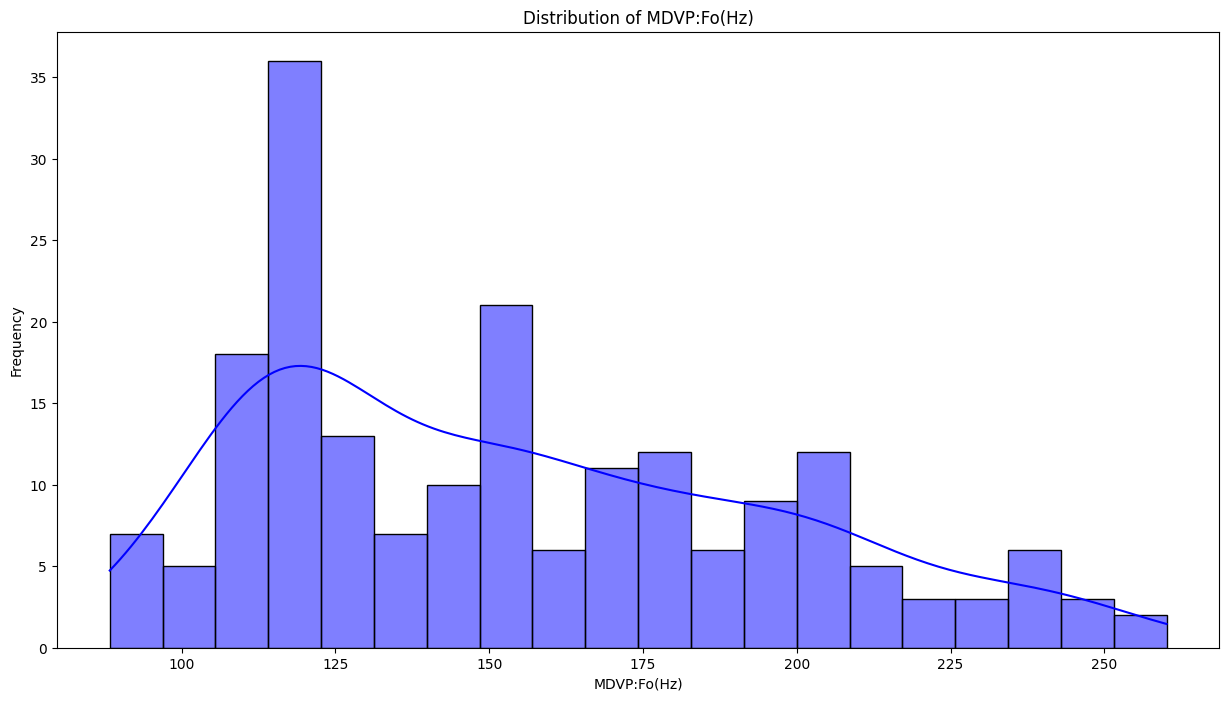

In [82]:
plt.figure(figsize=(15, 8))

# Plot the distribution of 'MDVP:Fo(Hz)'
sns.histplot(data['MDVP:Fo(Hz)'], bins=20, kde=True, color='blue')

# Set the title and labels
plt.title('Distribution of MDVP:Fo(Hz)')
plt.xlabel('MDVP:Fo(Hz)')
plt.ylabel('Frequency')

# Show the plot
plt.show()

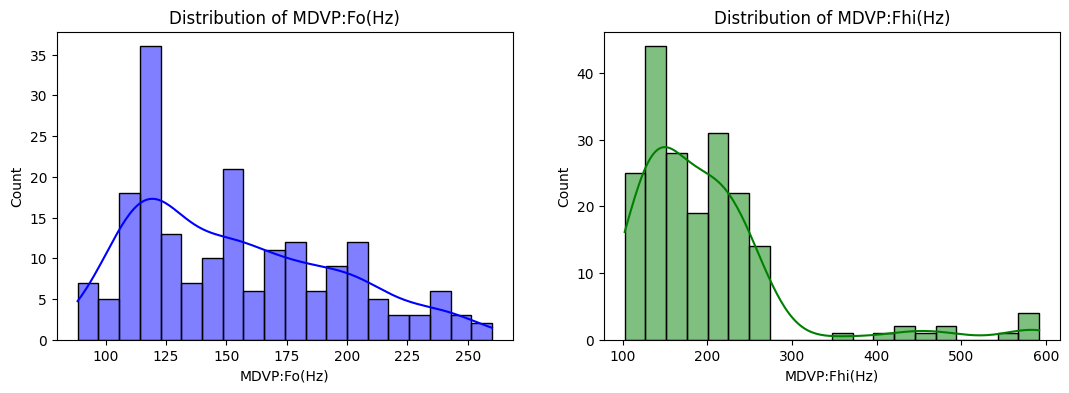

In [83]:
plt.figure(figsize=(20, 10))
plt.subplots_adjust(hspace=0.5)

# Plot multiple distributions
plt.subplot(2, 3, 1)
sns.histplot(data['MDVP:Fo(Hz)'], bins=20, kde=True, color='blue')
plt.title('Distribution of MDVP:Fo(Hz)')

plt.subplot(2, 3, 2)
sns.histplot(data['MDVP:Fhi(Hz)'], bins=20, kde=True, color='green')
plt.title('Distribution of MDVP:Fhi(Hz)')

# Add more subplots for other variables as needed

# Show the plot
plt.show()


<Figure size 1500x800 with 0 Axes>

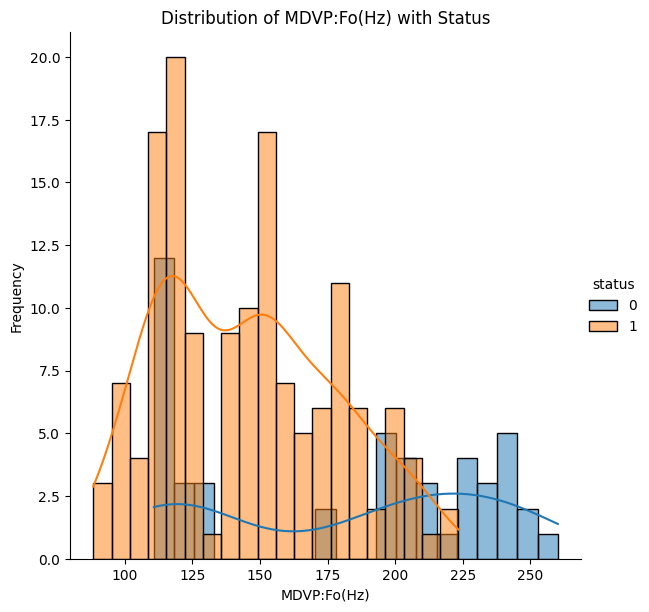

In [84]:
plt.figure(figsize=(15, 8))

# Create a FacetGrid with 'status' as hue
g = sns.FacetGrid(data, hue='status', height=6)
g.map(sns.histplot, 'MDVP:Fo(Hz)', bins=20, kde=True, alpha=0.5)

# Set the title and labels
plt.title('Distribution of MDVP:Fo(Hz) with Status')
plt.xlabel('MDVP:Fo(Hz)')
plt.ylabel('Frequency')

# Add a legend
g.add_legend()

# Show the plot
plt.show()


<Figure size 1500x1000 with 0 Axes>

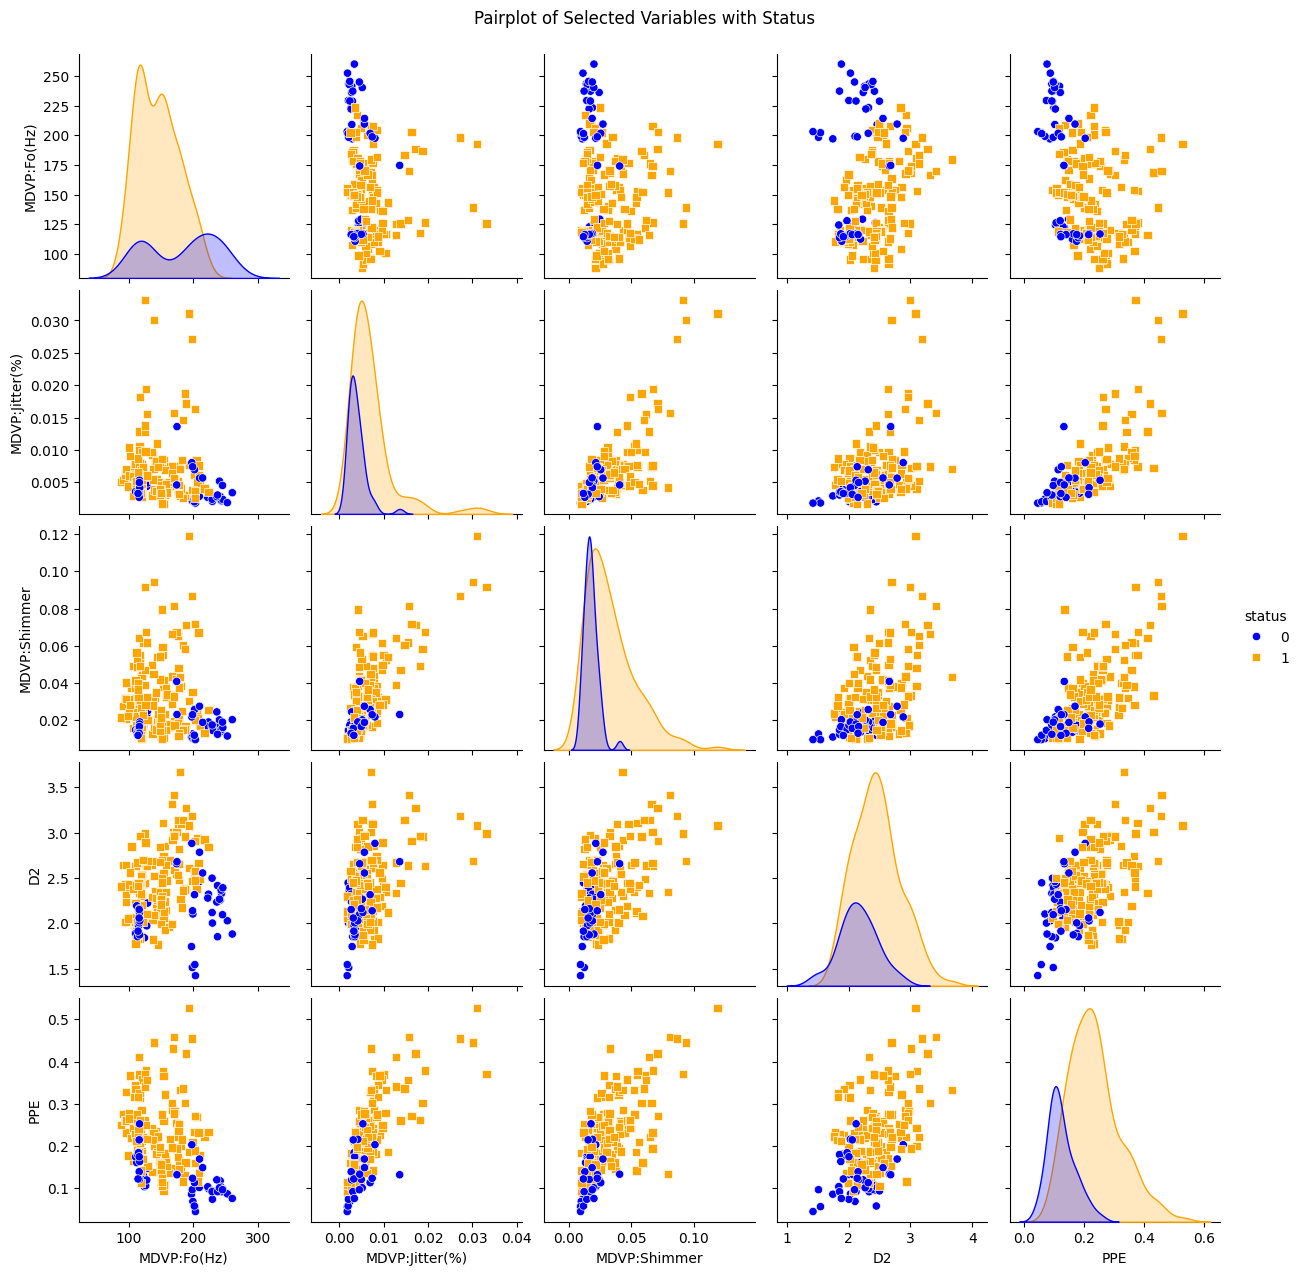

In [85]:
# Select relevant variables
selected_vars = ['MDVP:Fo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Shimmer', 'D2', 'PPE', 'status']

# Create a DataFrame with selected variables
selected_data = data[selected_vars]

# Create a pairplot
plt.figure(figsize=(15, 10))
sns.pairplot(selected_data, hue='status', diag_kind='kde', markers=['o', 's'], palette={0: 'blue', 1: 'orange'})

# Set the title
plt.suptitle('Pairplot of Selected Variables with Status', y=1.02)

# Show the plot
plt.show()

# Data Cleaning and Exploration
we will use pandas to clean our data and Extract important information from the features we have and knowing the types of data contained in it so that we can transform the data into the appropriate form for machine learning algorithms.

In [86]:
# show information about dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

In [87]:
# show statistical description for dataset
data.describe()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


In [88]:
# detect the number of missing values in each colum
missing_values = data.isnull().sum()
missing_values

name                0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64

In [89]:
data['status'].value_counts()

status
1    147
0     48
Name: count, dtype: int64

In [114]:
# Drop unnecessary column
data = data.drop('name', axis=1)

# Calculate z-score for each feature
z_scores = (data - data.mean()) / data.std()

# Remove outliers using the standard threshold = 3
data = data[(z_scores < 3).all(axis=1)]

# Check that the number of samples equals 181 and the number of features equals 13
print("Number of samples after removing outliers:", data.shape[0])
print("Number of features after removing outliers:", data.shape[1])

Number of samples after removing outliers: 181
Number of features after removing outliers: 23


In [115]:
# Calculate the correlation coefficient between each pair of features
correlation_matrix = data.corr()

# Identify columns with strong correlations (more than 0.8 or less than -0.8)
strong_correlation = np.where(np.abs(correlation_matrix) > 0.8)

# Drop the column if it has a strong correlation with any other column
for col1, col2 in zip(*strong_correlation):
    if col1 != col2 and col1 < col2:
        if col1 in data.columns and col2 in data.columns:
            data = data.drop(data.columns[col2], axis=1)

In [116]:
data.shape

(181, 23)

# Balancing the data
We noticed that the data we have is unbalanced, and in order for the result that we will obtain to be fair and so that the algorithm is not biased, we will balance the data using one of the data augmentation techniques so that the number of patient samples becomes equal to the number of healthy people’s samples.

In [117]:
# Shuffle the dataset
data = shuffle(data, random_state=42)

In [118]:
# Separate features (X) and target variable (y)
X = data.drop('status', axis=1)
y = data['status']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("x_train shape is: {}".format(X_train.shape))
print("y_train shape is: {}".format(y_train.shape))
print("X_test shape is: {}".format(X_test.shape))
print("y_test shape is: {}".format(y_test.shape))

x_train shape is: (126, 22)
y_train shape is: (126,)
X_test shape is: (55, 22)
y_test shape is: (55,)


In [119]:
# Display class distribution before balancing for training set
print("Class distribution before balancing for training set:")
print(y_train.value_counts())

Class distribution before balancing for training set:
status
1    92
0    34
Name: count, dtype: int64


In [120]:
# Apply SMOTE to balance the training set
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Display class distribution after balancing for training set
print("\nClass distribution after balancing for training set:")
y_train_balanced.value_counts()


Class distribution after balancing for training set:


status
0    92
1    92
Name: count, dtype: int64

In [121]:
y_test.value_counts()

status
1    43
0    12
Name: count, dtype: int64

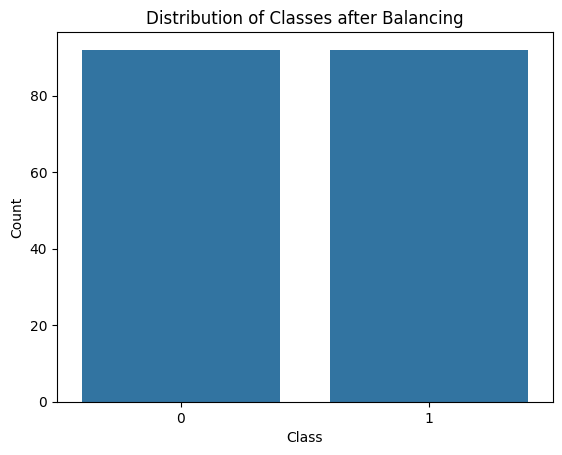

In [122]:
# Calculate class distribution after balancing
class_distribution = pd.Series(y_train_balanced).value_counts()

# Plot the class distribution
sns.barplot(x=class_distribution.index, y=class_distribution.values)
plt.title('Distribution of Classes after Balancing')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

# feature selection
Here we will use one of the feature selection techniques to choose a number of features that will be input to the machine learning algorithms, as we will not train the algorithm on all the features in the dataset, but rather we will choose the best of these features.

In [123]:
# Selecting the features based on their names
selected_features = [
    'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)',
    'MDVP:Shimmer', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2'
]

# Filter the training dataset to include only the selected features
X_train = X_train_balanced[selected_features]

# Filter the testing dataset to include only the selected features
X_test = X_test[selected_features]

# Scaling
We will use scaling techniques to make the features in the same field. This step is very important and will make the features equally important in the model. the we will split our data to train and test (80% for training and 20% for testing).

In [124]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the features
X_train = scaler.fit_transform(X_train)

X_test = scaler.fit_transform(X_test)

# Reduce data dimensionality
we will reduce the number of features using PCA algorithm.

In [125]:
# Compute the covariance matrix
cov_matrix = np.cov(X_train.T)

# Compute the eigenvectors and eigenvalues of the covariance matrix
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Select the top eigenvectors based on the explained variance
total_variance = sum(eigenvalues)
explained_variance_ratio = eigenvalues / total_variance
explained_variance_ratio_cumsum = np.cumsum(explained_variance_ratio)

# Choose the number of components to retain based on the explained variance ratio
n_components = 9

# Transform the original dataset into the new feature space
pca = PCA(n_components=n_components)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

In [126]:
# Get the names of the selected features
selected_feature_indices = pca.components_

# Assuming you have a list of feature names, you can use the selected indices to get the names
selected_features = [selected_features[i] for i in range(n_components)]

In [127]:
selected_features

['MDVP:Fo(Hz)',
 'MDVP:Fhi(Hz)',
 'MDVP:Flo(Hz)',
 'MDVP:Jitter(%)',
 'MDVP:Shimmer',
 'NHR',
 'HNR',
 'RPDE',
 'DFA']

***Second,*** we will deal with **hand writing images dataset** (parkinson and healthy) people, we will **extract features** from it and then we will merge the features with features that extracted from voice dataset.
*note:* this approach called ***early fusion***. you can understand this approach with this image:



![image](method.png)

In [128]:
# import modules
from imutils import paths
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from skimage import feature
import cv2
import numpy as np
import os
import joblib

In [129]:
# Function to extract HOG features from an image
def hog_features(image):
    features = feature.hog(image, orientations=9,
                           pixels_per_cell=(10, 10), cells_per_block=(2, 2),
                           transform_sqrt=True, block_norm="L1")
    return features
# Function to process images in a directory and extract features and labels
def process_images(directory_path):
    image_paths = list(paths.list_images(directory_path))
    data = []
    labels = []
    for img_path in image_paths:
        label = img_path.split(os.path.sep)[-2] # Extract label from image path
        img = cv2.imread(img_path) # Read image
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # Convert to grayscale
        img = cv2.resize(img, (250, 250), fx=0.5, fy=0.5) # Resize image
        img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1] # Apply thresholding
        features = hog_features(img) # Extract HOG features
        data.append(features)
        labels.append(label)
    return (np.array(data), np.array(labels))

# Function to train a RandomForestClassifier model and evaluate its performance
def extract_features(data_directory):
    training_path = os.path.sep.join([data_directory, "training"])
    testing_path = os.path.sep.join([data_directory, "testing"])
    train_data, train_labels = process_images(training_path)
    test_data, test_labels = process_images(testing_path)
    encoder = LabelEncoder()
    train_labels = encoder.fit_transform(train_labels)
    test_labels = encoder.transform(test_labels)

    return train_data, test_data, train_labels, test_labels

In [130]:
data_directory = "/content/drive/MyDrive/multimodal project/datasets/drawings"

imgx_train, imgx_test, imy_train, imy_test = extract_features(data_directory)

***now,*** we will merge features for training and testing dataset.

In [131]:
# in training dataset
# Combine features and labels for patients
X_train_patients = np.concatenate((X_train[y_train_balanced == 1], imgx_train[imy_train == 1]), axis = 1)
y_train_patients = np.ones(X_train_patients.shape[0])

# Combine features and labels for healthy
X_train_non_patients = np.concatenate((X_train[y_train_balanced == 0], imgx_train[imy_train == 0]), axis = 1)
y_train_non_patients = np.zeros(X_train_non_patients.shape[0])

# Ensure balanced dataset by taking the minimum number of samples from each class
min_samples = min(X_train_patients.shape[0], X_train_non_patients.shape[0])
X_train_combined = np.concatenate((X_train_patients[:min_samples], X_train_non_patients[:min_samples]))
y_train_combined = np.concatenate((y_train_patients[:min_samples], y_train_non_patients[:min_samples]))

# Shuffle the combined dataset
combined_indices = np.arange(X_train_combined.shape[0])
np.random.shuffle(combined_indices)
X_train_combined = X_train_combined[combined_indices]
y_train_combined = y_train_combined[combined_indices]

print("Shape of combined features:", X_train_combined.shape)
print("Shape of combined labels:", y_train_combined.shape)


Shape of combined features: (184, 20745)
Shape of combined labels: (184,)


In [132]:
# in testing dataset
# Combine features and labels for patients
X_test_patients = np.concatenate((X_test[y_test == 1], imgx_test[imy_test == 1]), axis = 1)
y_test_patients = np.ones(X_test_patients.shape[0])

# Combine features and labels for non-patients
X_test_non_patients = np.concatenate((X_test[y_test == 0], imgx_test[imy_test == 0]), axis = 1)
y_test_non_patients = np.zeros(X_test_non_patients.shape[0])

# Ensure balanced dataset by taking the minimum number of samples from each class
samples = X_test_patients.shape[0] +  X_test_non_patients.shape[0]
X_test_combined = np.concatenate((X_test_patients[:samples], X_test_non_patients[:samples]))
y_test_combined = np.concatenate((y_test_patients[:samples], y_test_non_patients[:samples]))

# Shuffle the combined dataset
combined_indices = np.arange(X_test_combined.shape[0])
np.random.shuffle(combined_indices)
X_test_combined = X_test_combined[combined_indices]
y_test_combined = y_test_combined[combined_indices]

print("Shape of combined test features:", X_test_combined.shape)
print("Shape of combined test labels:", y_test_combined.shape)


Shape of combined test features: (55, 20745)
Shape of combined test labels: (55,)


# Trainig and Evaluation
we will use machine learning algorithms, and we will improve it with Grid search Technique, we will use Random Forest and SVM algorithmns and compare them.

In [136]:
# function to train the model
def train_model(model, X_train, y_train):

    # Train the model
    model.fit(X_train, y_train)

# function to evaluate the model
def evaluate_model(model, X, y):

    # Predict
    y_pred = model.predict(X)

    # Get evaluation metrics
    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    conf_matrix = confusion_matrix(y, y_pred)

    print("Metrics:")
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)

    # Plot confusion matrix
    sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.show()

    print("Classification Report:")
    print(classification_report(y, y_pred))

# Function to save a trained model to a file
def save_model(model, model_path):
    joblib.dump(model, model_path)

# Function to load a trained model from a file
def load_model(model_path):
    return joblib.load(model_path)

in each algorithm we will train and evaluate the model and visualize accuracy and error for test data in each it and draw confusion matrix for testing data.
# Random Forest Algorithm


In [134]:
# Initialize the Random Forest model
random_forest_model = RandomForestClassifier(random_state=42)

# train RF model
train_model(random_forest_model, X_train_combined, y_train_combined)

In [ ]:
# save the model
model_path = "/content/drive/MyDrive/multimodal project/models/Rf.pkl"
save_model(random_forest_model, model_path)

In [146]:
# Load the saved model from the file
model_path = "/content/drive/MyDrive/multimodal project/models/Rf.pkl"
loaded_model = load_model(model_path)

Evaluation RF model on Training dataset:
Metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


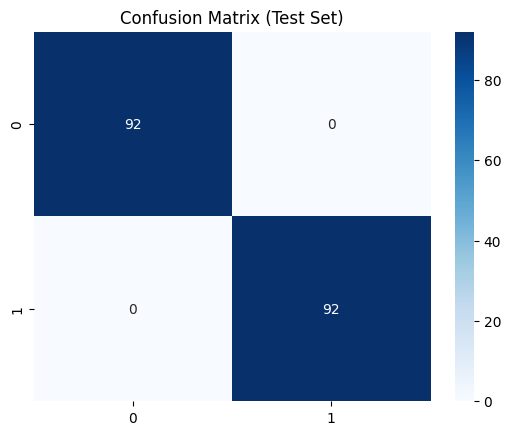

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        92
         1.0       1.00      1.00      1.00        92

    accuracy                           1.00       184
   macro avg       1.00      1.00      1.00       184
weighted avg       1.00      1.00      1.00       184



In [147]:
# evaluate RF mdoel on Training set
print("Evaluation RF model on Training dataset:")
evaluate_model(loaded_model, X_train_combined, y_train_combined)

Evaluation RF model on testing dataset:
Metrics:
Accuracy: 0.9272727272727272
Precision: 1.0
Recall: 0.9069767441860465
F1 Score: 0.951219512195122


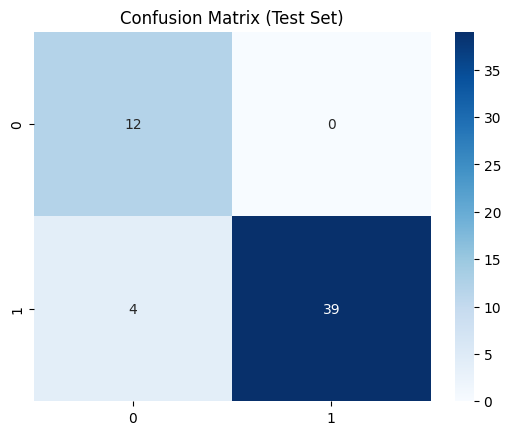

Classification Report:
              precision    recall  f1-score   support

         0.0       0.75      1.00      0.86        12
         1.0       1.00      0.91      0.95        43

    accuracy                           0.93        55
   macro avg       0.88      0.95      0.90        55
weighted avg       0.95      0.93      0.93        55



In [148]:
# evaluate RF mdoel on Testing set
print("Evaluation RF model on testing dataset:")
evaluate_model(loaded_model, X_test_combined, y_test_combined)

### Grid search
we will apply Grid Search Algorithm to improve the model accuracy.

In [ ]:
# Define the hyperparameters grid
param_grid = {
    'n_estimators': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 200, 400, 800, 1600],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion' : ['gini', 'entropy']
}

# Initialize RandomForestClassifier
random_forest_model = RandomForestClassifier()

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=random_forest_model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Train the grid search
grid_search.fit(X_train_combined, y_train_combined)

# Print the best hyperparameters found
print("Best hyperparameters:", grid_search.best_params_)

# Get the best model
best_rf_model = grid_search.best_estimator_

# Evaluate the best model on testing set
print("Evaluation of the best RF model on the testing set:")
evaluate_model(best_rf_model, X_test_combined, y_test_combined)


Best hyperparameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Evaluation of the best RF model on the testing set:
Metrics:
Accuracy: 0.8909090909090909
Precision: 1.0
Recall: 0.8604651162790697
F1 Score: 0.9249999999999999
Confusion Matrix:
 [[12  0]
 [ 6 37]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.67      1.00      0.80        12
         1.0       1.00      0.86      0.92        43

    accuracy                           0.89        55
   macro avg       0.83      0.93      0.86        55
weighted avg       0.93      0.89      0.90        55



In [ ]:
# save the model
model_path = "/content/drive/MyDrive/multimodal project/models/Rf_GridSerach.pkl"
save_model(best_rf_model, model_path)

In [149]:
# Load the saved model from the file
model_path = "/content/drive/MyDrive/multimodal project/models/Rf_GridSerach.pkl"
loaded_model = load_model(model_path)

Evaluation of the best RF model on the training set:
Metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


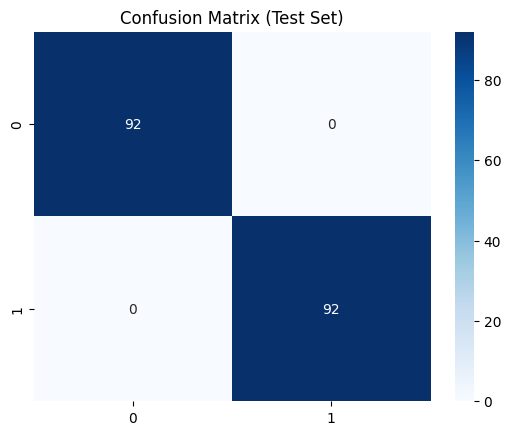

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        92
         1.0       1.00      1.00      1.00        92

    accuracy                           1.00       184
   macro avg       1.00      1.00      1.00       184
weighted avg       1.00      1.00      1.00       184



In [150]:
# Evaluate the best model on training set
print("Evaluation of the best RF model on the training set:")
evaluate_model(loaded_model, X_train_combined, y_train_combined)

Evaluation of the best RF model on the testing set:
Metrics:
Accuracy: 0.8909090909090909
Precision: 1.0
Recall: 0.8604651162790697
F1 Score: 0.9249999999999999


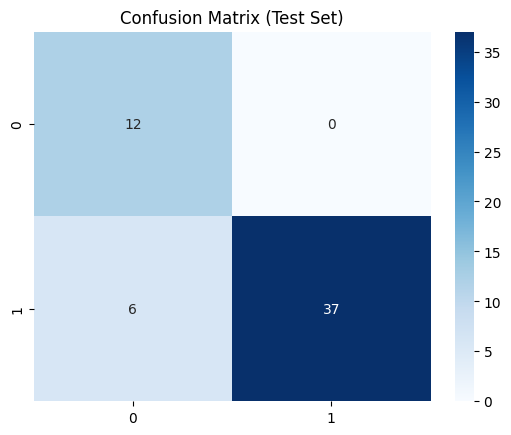

Classification Report:
              precision    recall  f1-score   support

         0.0       0.67      1.00      0.80        12
         1.0       1.00      0.86      0.92        43

    accuracy                           0.89        55
   macro avg       0.83      0.93      0.86        55
weighted avg       0.93      0.89      0.90        55



In [144]:
# Evaluate the best model on testing set
print("Evaluation of the best RF model on the testing set:")
evaluate_model(loaded_model, X_test_combined, y_test_combined)

# SVM
we will apply SVM Algorithm to train the model, and we will us Grid Search Algorithm with Cross Validation to improve the performance.

In [ ]:
from sklearn.svm import SVC

# Initialize SVM classifier
svm_classifier = SVC()

# Training SVM model
train_model(svm_classifier, X_train_combined, y_train_combined)

In [ ]:
# save the model
model_path = "/content/drive/MyDrive/multimodal project/models/SVM.pkl"
save_model(best_rf_model, model_path)

In [151]:
# Load the saved model from the file
model_path = "/content/drive/MyDrive/multimodal project/models/SVM.pkl"
loaded_model = load_model(model_path)

Evaluation RF model on Training dataset:
Metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


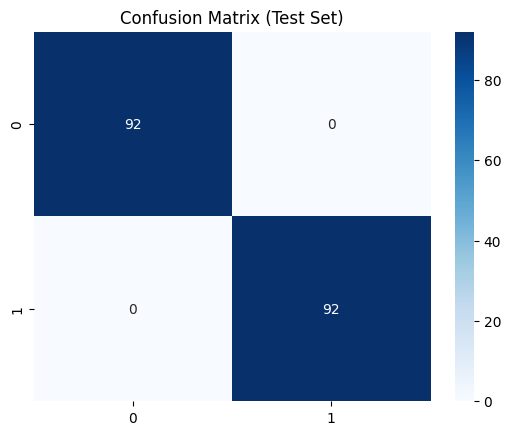

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        92
         1.0       1.00      1.00      1.00        92

    accuracy                           1.00       184
   macro avg       1.00      1.00      1.00       184
weighted avg       1.00      1.00      1.00       184



In [153]:
# evaluate SVM model on training set
print("Evaluation RF model on Training dataset:")
evaluate_model(loaded_model, X_train_combined, y_train_combined)

Evaluation RF model on testing dataset:
Metrics:
Accuracy: 0.8909090909090909
Precision: 1.0
Recall: 0.8604651162790697
F1 Score: 0.9249999999999999


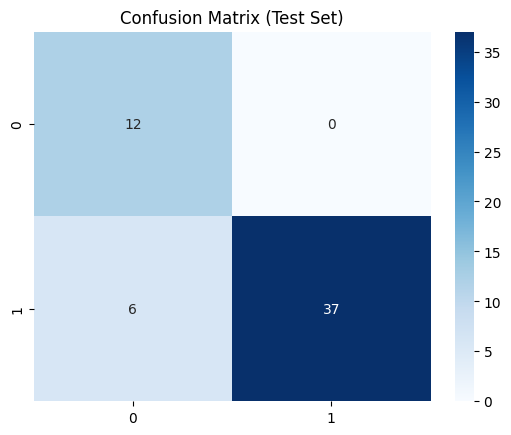

Classification Report:
              precision    recall  f1-score   support

         0.0       0.67      1.00      0.80        12
         1.0       1.00      0.86      0.92        43

    accuracy                           0.89        55
   macro avg       0.83      0.93      0.86        55
weighted avg       0.93      0.89      0.90        55



In [154]:
# evaluate SVM model on Testing set
print("Evaluation RF model on testing dataset:")
evaluate_model(loaded_model, X_test_combined, y_test_combined)

## Grid Search for SVM

In [ ]:
# Define the hyperparameters grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 100],  # Penalty parameter C
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],  # Kernel type
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1, 2]  # Kernel coefficient
}

# Initialize SVM classifier
svm_classifier = SVC()

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=svm_classifier, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Train the grid search
grid_search.fit(X_train_combined, y_train_combined)

# Print the best hyperparameters found
print("Best hyperparameters:", grid_search.best_params_)

# Get the best model
best_svm_model = grid_search.best_estimator_

# Evaluate the best model on testing set
print("Evaluation of the best SVM model on the testing set:")
evaluate_model(best_svm_model, X_test_combined, y_test_combined)

Best hyperparameters: {'C': 0.001, 'gamma': 0.1, 'kernel': 'poly'}
Evaluation of the best SVM model on the testing set:
Metrics:
Accuracy: 0.8909090909090909
Precision: 1.0
Recall: 0.8604651162790697
F1 Score: 0.9249999999999999
Confusion Matrix:
 [[12  0]
 [ 6 37]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.67      1.00      0.80        12
         1.0       1.00      0.86      0.92        43

    accuracy                           0.89        55
   macro avg       0.83      0.93      0.86        55
weighted avg       0.93      0.89      0.90        55



In [ ]:
# save the model
model_path = "/content/drive/MyDrive/multimodal project/models/SVM_GridSearch.pkl"
save_model(best_rf_model, model_path)

In [158]:
# Load the saved model from the file
model_path = "/content/drive/MyDrive/multimodal project/models/SVM_GridSearch.pkl"
loaded_model = load_model(model_path)

Evaluation of the best SVM model on the training set:
Metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


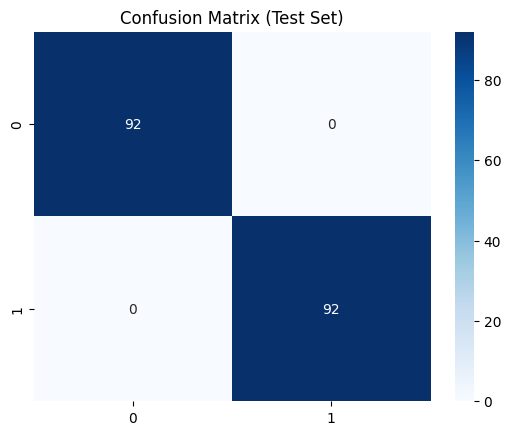

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        92
         1.0       1.00      1.00      1.00        92

    accuracy                           1.00       184
   macro avg       1.00      1.00      1.00       184
weighted avg       1.00      1.00      1.00       184



In [159]:
# Evaluate the best model on training set
print("Evaluation of the best SVM model on the training set:")
evaluate_model(loaded_model, X_train_combined, y_train_combined)

Evaluation of the best SVM model on the testing set:
Metrics:
Accuracy: 0.8909090909090909
Precision: 1.0
Recall: 0.8604651162790697
F1 Score: 0.9249999999999999


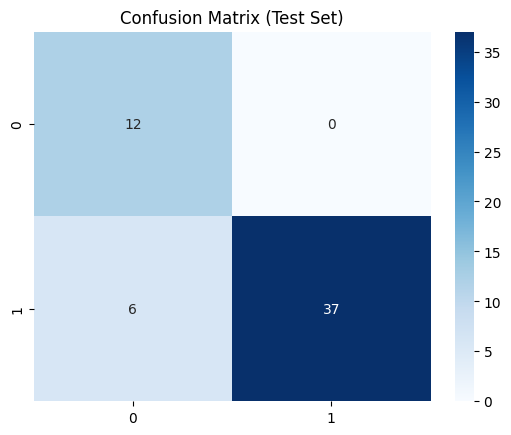

Classification Report:
              precision    recall  f1-score   support

         0.0       0.67      1.00      0.80        12
         1.0       1.00      0.86      0.92        43

    accuracy                           0.89        55
   macro avg       0.83      0.93      0.86        55
weighted avg       0.93      0.89      0.90        55



In [160]:
# Evaluate the best model on testing set
print("Evaluation of the best SVM model on the testing set:")
evaluate_model(loaded_model, X_test_combined, y_test_combined)

## Using the model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import librosa
import numpy as np
from sklearn.preprocessing import StandardScaler
from IPython.display import Audio, display
import joblib
import os
import pickle
import cv2
import matplotlib.pyplot as plt
import joblib
from skimage import feature

In [ ]:
# Function to load a trained model from a file
def load_model(model_path):
    return joblib.load(model_path)

def play_audio(audio_file_path):
    display(Audio(audio_file_path, autoplay=True))

def Extract_voice_features(audio_file_path, scaler=None):
    # Load the audio file
    samples, sample_rate = librosa.load(audio_file_path, sr=None)

    # Extract features
    fo, fhi, flo, jitter, shimmer, nhr, hnr, rpde, dfa = librosa.feature.mfcc(y=samples, sr=sample_rate, n_mfcc=9)

    # Calculate mean of each feature
    voice_features_mean = [fo.mean(), fhi.mean(), flo.mean(), jitter.mean(), shimmer.mean(), nhr.mean(), hnr.mean(), rpde.mean(), dfa.mean()]

    # Convert selected features to array
    voice = np.array(voice_features_mean)

    # If scaler is provided, scale the features
    if scaler:
        voice_scaled = scaler.fit_transform(voice.reshape(-1, 1)).reshape(1, -1)
    else:
        voice_scaled = voice.reshape(1, -1)

    return voice_scaled

# Function to extract HOG features from an image
def Extract_img_features(image):
    img = cv2.imread(image)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, (250, 250), fx=0.5, fy=0.5)
    img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]
    features = feature.hog(img, orientations=9,
                           pixels_per_cell=(10, 10), cells_per_block=(2, 2),
                           transform_sqrt=True, block_norm="L1")
    return features.reshape(1, -1), img

def predict_parkinsons(audio_path, image_path, model):

  voice_features = Extract_voice_features(audio_path, scaler)

  img_features, img = Extract_img_features(image_path)

  # Concatenate voice and image features
  model_input = np.concatenate((voice_features, img_features), axis=1)

  # Make predictions
  prediction = model.predict(model_input)

  # Play the audio file
  play_audio(audio_path)

  # Display the image
  plt.imshow(img, cmap='gray')
  plt.axis('off')

  if prediction == 1:
    return "You are sick"
  else:
    return "You do not have Parkinson's disease"

# Initialize the StandardScaler
scaler = StandardScaler()

In [ ]:
# Load the saved model from the file
model_path = "/content/drive/MyDrive/multimodal project/models/Rf.pkl"
loaded_model = load_model(model_path)

In [ ]:
audio_path = "/content/drive/MyDrive/multimodal project/datasets/voice/records for testing/pd3.wav"
image_path = "/content/drive/MyDrive/multimodal project/datasets/drawings/images for Using/hc1.png"

You do not have Parkinson's disease


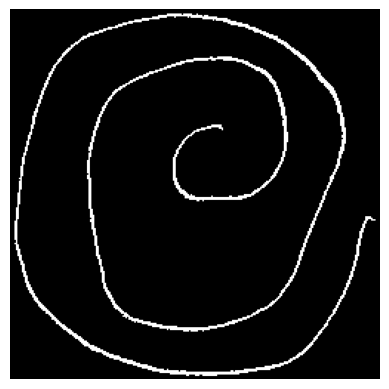

In [ ]:
predictions = predict_parkinsons(audio_path, image_path, loaded_model)
print(predictions)